In [1]:
## Peizhi Yan 2025 Copyright.

"""
In this demo we train a simple transformer network model for machine translation task
"""

import torch
import torch.nn.functional as F
import numpy as np
import random
import matplotlib.pyplot as plt
from time import time
from tqdm import tqdm

from transformer_utils import PositionalEncoding, generate_mask, SimpleTokenizer
from transformer_lite import GPT

# device = 'cpu'
# select the device to run the model (priority: cuda > mps > cpu)
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print('Computing Device: ', device)

# define some hyperparameters
BATCH_SIZE = 16
MAX_LENGTH = 60     # the maximum amount of "tokens" in a sequence
DIMENSION = 128     # the dimension of each "token" embedding
ATTN_HEADS = 8      # the number of attention heads
NUM_BLOCKS = 6      # the number of transformer encoder/decoder blocks


Computing Device:  cuda


### Positional Encoding

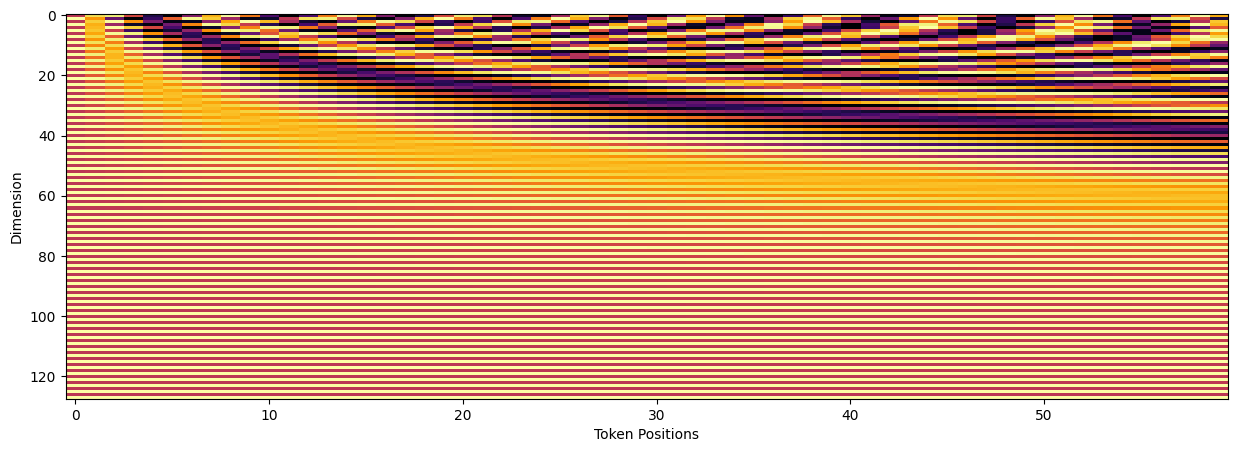

In [2]:
PE = PositionalEncoding(max_length=MAX_LENGTH, dim=DIMENSION, device=device)
x = torch.zeros([1, MAX_LENGTH, DIMENSION]).to(device) # batch = 1, sequence length = 100
x_pe = PE(x)
plt.figure(figsize=(15,5))
plt.imshow(x_pe[0].T.cpu(), cmap='inferno', aspect='auto')
plt.xlabel('Token Positions'); plt.ylabel('Dimension')
plt.show()


### Data, Tokenization, Embedding

Tokens:  ['<BEGIN>', 'W', 'i', 't', 'h', ' ', 'b', 'a', 't', 's', ' ', 'a', 'n', 'd', ' ', 'c', 'l', 'u', 'b', 's', '?', ' ', 'T', 'h', 'e', ' ', 'm', 'a', 't', 't', 'e', 'r', '?', ' ', 's', 'p', 'e', 'a', 'k', ',', ' ', 'I', ' ', 'p', 'r', 'a', 'y', ' ', 'y', 'o', 'u', '.', '<EOS>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>']
Text reconstructed from tokens:  With bats and clubs? The matter? speak, I pray you.
torch.Size([1, 60, 128])


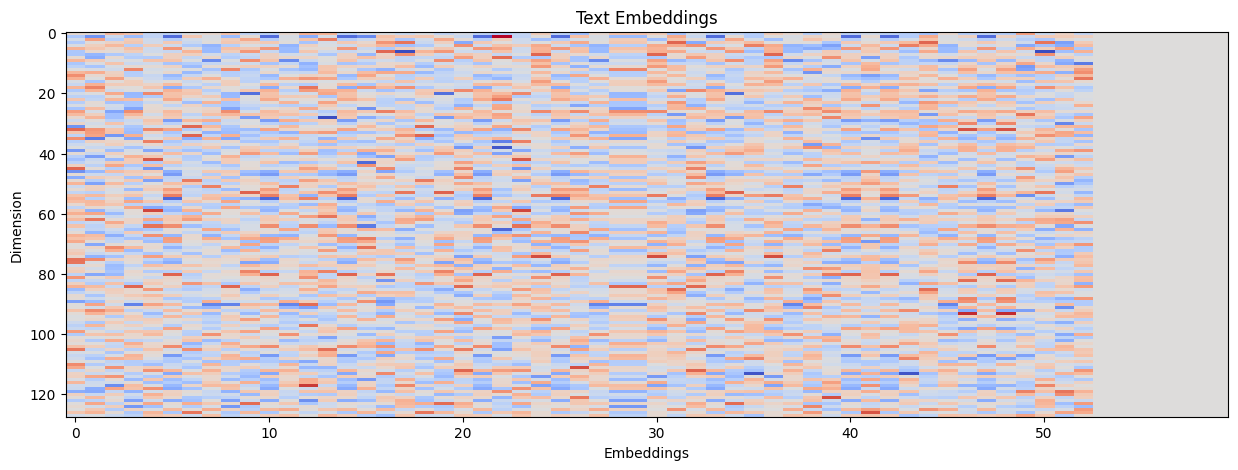

In [3]:
# load the data
texts = []
data_path = './data/tinyshakespeare.txt'
with open(data_path, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if len(line) > 0:
            texts.append(line)

corpus = texts

# create a simple tokenizer from the corpus
tokenizer = SimpleTokenizer(texts=corpus, max_length=MAX_LENGTH)

# test the tokenizer
indices = tokenizer.get_indices(text=texts[66])   # tokenize the text and get indices
tokens = tokenizer.get_tokens(indices=indices)       # convert the indices back to tokens
print("Tokens: ", tokens)
print("Text reconstructed from tokens: ", tokenizer.get_text_from_tokens(tokens=tokens)) # convert the list of tokens to text

# embedding
padding_idx = tokenizer.token_to_index['<EMPTY>']
num_embeddings = tokenizer.num_tokens # get the vocabulary size
token_embedding = torch.nn.Embedding(num_embeddings=num_embeddings, embedding_dim=DIMENSION, 
                                     padding_idx=padding_idx, device=device)

# test token embedding
embeddings = token_embedding(torch.LongTensor([indices]).to(device)) # get the token embeddings
print(embeddings.shape)
plt.figure(figsize=(15,5))
plt.imshow(embeddings[0, :, :].detach().T.cpu(), cmap='coolwarm', aspect='auto')
plt.title('Text Embeddings'); plt.xlabel('Embeddings'); plt.ylabel('Dimension')
plt.show()



In [4]:
# prepare the training data
text_indices = [tokenizer.get_indices(text=text) for text in texts] # tokenize the text and get indices of tokens
end_indices = [] # records the end token <EOS> index of sequence
for i in range(len(text_indices)):
    flag = False
    for j in range(len(text_indices[i])):
        if text_indices[i][j] == tokenizer.token_to_index['<EOS>']:
            end_indices.append(j)
            flag = True
            break
    if not flag:
        # end token not found in sequence
        end_indices.append(len(text_indices[i])-1) # set the end index to the last token in the sequence

#print(end_indices)
print('Number of sequences: ', len(text_indices))
if len(end_indices) != len(text_indices):
    # double check whether the number of sequences and end indices match
    raise ValueError('The number of sequences and end indices do not match!')


Number of sequences:  32777


### Create Model

In [5]:
# get the vocabulary size (represented by the number of possible tokens in the dictionary)
VOCABULARY_SIZE = tokenizer.num_tokens

# create the transformer model
gpt = GPT(dim=DIMENSION, num_heads=ATTN_HEADS, num_blocks=NUM_BLOCKS, 
          max_length=MAX_LENGTH, vocabulary_size=VOCABULARY_SIZE, device=device)

# optional: compile the model to optimize the performance, needs torch 2.0 or above
# gpt = torch.compile(gpt)

# create the optimizer
optimizer = torch.optim.Adam(list(gpt.parameters()), lr=1e-6)

gpt.train()

GPT(
  (positional_encoding): PositionalEncoding()
  (decoder_blocks): ModuleList(
    (0-5): 6 x GPTBlock(
      (self_attn): MultiHeadAttention(
        (Wq): Linear(in_features=128, out_features=128, bias=False)
        (Wk): Linear(in_features=128, out_features=128, bias=False)
        (Wv): Linear(in_features=128, out_features=128, bias=False)
        (out): Linear(in_features=128, out_features=128, bias=False)
      )
      (ln1): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
      (ln2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
      (ffn): FeedForwardNetwork(
        (fc1): Linear(in_features=128, out_features=128, bias=True)
        (fc2): Linear(in_features=128, out_features=128, bias=True)
      )
    )
  )
  (output_layer): Linear(in_features=128, out_features=68, bias=True)
)

### Train

Note: this code assumes the batch size is one. 

In [6]:

NUM_ITERATIONS = 1000


# training loop
with tqdm(total=NUM_ITERATIONS) as pbar:
    iter_ = 0
    while iter_ < NUM_ITERATIONS:

        optimizer.zero_grad()

        # prepare training data
        idx = random.randint(0, len(texts)-1)  # select a random sentence
        end_index = end_indices[idx]
        cut_index = random.randint(1, end_index-1) # randomly cut the rest of a sequence
        with torch.no_grad():
            # prepare the data
            targets = torch.tensor(text_indices[idx], dtype=torch.long)[None].to(device)     # [1, L]
            target_embeddings = token_embedding(targets)                                     # [1, L, D]
            mask = torch.zeros([1, MAX_LENGTH], dtype=torch.uint8).to(device)                # [1, L]
            mask[:,:cut_index] = 1 # un-mask the tokens before the cut index
            masked_targets = targets.clone()
            masked_targets[:, cut_index:] = -1  # mask future tokens

        # forward pass
        logits = gpt.decode(Y=target_embeddings, mask=mask)                                  # [1, L, V] (V = vocabulary size)
        if iter_ % 10 == 0:
            print(torch.argmax(logits[0], dim=-1).cpu().numpy())

        # compute cross-entropy loss
        # loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        loss = F.cross_entropy(
            logits.view(-1, logits.size(-1)),
            masked_targets.view(-1),
            ignore_index=-1
        )

        if torch.isnan(loss) == False:
            loss.backward()
            optimizer.step()
            pbar.set_postfix({'Loss': loss.item()})

        pbar.update(1)
        iter_ += 1

        # Optional logging
        if iter_ % 100 == 0:
            pred_tokens = torch.argmax(logits[0], dim=-1)
            print("Predicted:", pred_tokens[cut_index].cpu().tolist())
            print("Target:   ", targets[0, cut_index].cpu().tolist())



  0%|          | 0/1000 [00:00<?, ?it/s]

tensor([[[-3.5856e-02,  4.7794e-01,  1.1658e-01, -1.7701e-01, -1.6449e-01,
           1.6928e-01,  3.5042e-01, -1.6408e-01, -1.2568e-01, -2.4977e-01,
           4.2725e-02,  9.0907e-02,  1.8480e-01, -3.3062e-01, -4.3120e-02,
           2.2293e-01],
         [-8.9967e-02,  8.9537e-02,  1.7802e-01, -1.2903e-01,  1.1887e-01,
          -1.2284e-01,  3.1072e-01, -4.0794e-02, -8.5167e-02, -8.1038e-02,
           6.1124e-02,  2.2754e-01,  1.3794e-01, -2.4616e-01,  2.8945e-02,
           2.6125e-01],
         [ 5.2166e-02,  8.0186e-03,  2.3428e-01, -4.5012e-02,  1.2872e-01,
          -1.6461e-01,  2.6100e-01, -1.4753e-02,  4.7100e-02, -1.4617e-02,
          -1.9932e-02,  2.0685e-01,  1.6589e-01, -1.3754e-01, -4.9099e-04,
           1.0077e-01],
         [-5.5093e-02,  1.0441e-01,  2.3813e-01, -4.3514e-03,  2.5525e-02,
          -7.6244e-02,  7.7073e-02,  7.6247e-02,  4.4184e-02,  6.0327e-02,
           4.6124e-03,  9.1493e-02,  1.3973e-01, -6.3368e-02, -3.4114e-02,
           1.2114e-01],
    

  0%|          | 1/1000 [00:00<12:09,  1.37it/s]

tensor([[[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],

  0%|          | 2/1000 [00:00<07:05,  2.34it/s]

...

  1%|          | 12/1000 [00:03<04:10,  3.94it/s]

tensor([[[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],

  1%|          | 12/1000 [00:03<04:57,  3.32it/s]

tensor([[[ 1.4238e-01, -9.9948e-02,  2.1672e-01, -6.3804e-02,  2.2105e-01,
          -1.3719e-01, -7.3231e-03,  1.8811e-01, -2.8176e-01, -5.2174e-02,
           3.2978e-01, -2.4306e-01, -3.7952e-01,  1.6763e-01,  3.5593e-01,
           4.4935e-02],
         [ 1.6308e-01,  1.3941e-01,  1.1368e-01,  1.7335e-01,  2.2544e-01,
          -2.2970e-01, -6.8895e-02,  1.9144e-02,  4.7086e-02, -1.8167e-02,
           7.7595e-02,  1.1685e-01, -1.1735e-01,  9.0957e-02, -1.4140e-02,
           1.6901e-01],
         [ 1.4874e-01, -4.7668e-02,  2.1474e-01,  1.5295e-01,  1.3880e-01,
          -2.6247e-01, -1.7821e-01,  1.1845e-01,  5.6139e-02,  9.5245e-03,
           2.0000e-01,  2.4907e-01, -7.6633e-02,  3.0040e-02,  1.4983e-04,
           5.5619e-02],
         [ 1.3992e-01, -1.2194e-01,  2.5571e-01,  1.6107e-01,  8.9156e-02,
          -2.7688e-01, -2.4463e-01,  1.6163e-01,  7.4357e-02,  2.7092e-02,
           2.5005e-01,  3.3588e-01, -3.6856e-02,  4.5209e-04, -1.3944e-02,
           4.5523e-03],
    

KeyboardInterrupt: 

In [ ]:
# prepare training data
#idx = random.randint(0, len(texts)-1)  # select a random sentence
print(texts[idx])
end_index = end_indices[idx]
cut_index = end_index - 1
with torch.no_grad():
    # prepare the input data
    targets = torch.tensor(text_indices[idx], dtype=torch.long)[None].to(device)     # [1, L]
    target_embeddings = token_embedding(targets)                                     # [1, L, D]
    target_embeddings[:, cut_index:] = 0 # set the embeddings after the cut index to zero
    mask = torch.zeros([1, MAX_LENGTH], dtype=torch.uint8).to(device)                # [1, L]
    mask[:cut_index] = 1 # un-mask the tokens before the cut index

# forward pass
logits = gpt.decode(Y=target_embeddings, mask=mask)                                  # [1, L, V] (V = vocabulary size)
print(logits.shape)

indices = torch.argmax(logits, dim=-1).cpu().numpy() # get the predicted indices
indices

# convert the indices back to tokens
tokens = tokenizer.get_tokens(indices=indices[0])       # convert the indices back to tokens
tokenizer.get_text_from_tokens(tokens=tokens) # convert the list of tokens to text

But if I thrive, the gain of my attempt
torch.Size([1, 60, 68])


'ut if I thrive, the gain of my attemp'

### Generate

In [ ]:


@torch.no_grad()
def generate_sentence(gpt, token_embedding, tokenizer, max_length=60):
    """
    Perform inference with the trained gpt model.

    Args:
        gpt: The trained GPT model.
        token_embedding: The embedding layer for tokens.
        tokenizer: The tokenizer object for converting between tokens and text.
        max_length: The maximum length of the generated target sequence.

    Returns:
        The generated sentence in tokenized form.
    """
    device = next(gpt.parameters()).device

    # Prepare the source sequence
    init_sequence = [[tokenizer.token_to_index['<EMPTY>'] for _ in range(MAX_LENGTH)]]      # [1, L]
    init_sequence[0][0] = tokenizer.token_to_index['<BEGIN>']  # Set the first token to <BEGIN>
    init_sequence = torch.tensor(init_sequence, dtype=torch.long).unsqueeze(0).to(device)   # [1, L]
    init_embeddings = token_embedding(init_sequence)                                        # [1, L, D]

    # Create initial target sequence
    target_sequence = tokenizer.get_indices(text="")   # tokenize the text and get indices
    generated_tokens = []
    for i in range(max_length):
        # Prepare the target embeddings
        target_tensor = torch.tensor(target_sequence, dtype=torch.long).unsqueeze(0).to(device)  # [1, L]
        target_embeddings = token_embedding(target_tensor)  # [1, T, D]

        # Parepare the target sequence mask
        mask = torch.zeros([1, MAX_LENGTH], dtype=torch.uint8).to(device)                       # [1, L]
        mask[:, :i+1] = 1  # Unmask only the tokens up to the current token

        # Decode step
        logits = gpt.decode(Y=target_embeddings, mask=mask)  # [1, T, V]
        # print(logits)
        # print(target_sequence)
        # break

        # Pass through the token generation head
        next_token_logits = logits[:, i+1, :]  # [1, V] - Get logits for the i-th token
        next_token_id = torch.argmax(next_token_logits, dim=-1).item()  # Get the predicted token
        next_token = tokenizer.index_to_token[next_token_id]  # Convert token index to token

        # Append the predicted token to the target sequence
        target_sequence[i+1] = next_token_id
        generated_tokens.append(next_token)
        print(generated_tokens)

        # Stop if <EOS> is generated
        if next_token == tokenizer.token_to_index["<EOS>"]:
            break

    # Convert token indices back to text
    generated_sentence = tokenizer.get_text_from_tokens(generated_tokens)

    return generated_sentence

# Example input sentence
source_text_inference = "sequence modelling and generation"  # In the source language
source_indices_inference = tokenizer.get_indices(text=source_text_inference)   # Convert text to token indices

# Perform inference
generated_sentence = generate_sentence(
    gpt=gpt,
    token_embedding=token_embedding,
    tokenizer=tokenizer,
    max_length=30
)

print(f"Generated sequence: {generated_sentence}")

['<EOS>']
['<EOS>', '<EMPTY>']
['<EOS>', '<EMPTY>', '<EMPTY>']
['<EOS>', '<EMPTY>', '<EMPTY>', '<EMPTY>']
['<EOS>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>']
['<EOS>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>']
['<EOS>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>']
['<EOS>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>']
['<EOS>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>']
['<EOS>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>']
['<EOS>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>']
['<EOS>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>']
['<EOS>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>']
['<EOS>', '<